In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.preprocessing import MinMaxScaler

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from utils import (
    eda_tabular
)
print("Imported successfully")

Imported successfully
Imported successfully


In [6]:
df = pd.read_csv("../datasets/spambase.csv")

print("First 5 Rows:")
display(df.head())

print("Dataset shape: ",df.shape)

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
missing = df.isnull().sum()
display(missing)

print(f"\nTotal Missing Values: {missing.sum()}")

duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

target = df.columns[-1]

print("\nTarget Column:", target)

print("\nClass Distribution:")
display(df[target].value_counts())

print("\nClass Distribution (%):")
display((df[target].value_counts(normalize=True) * 100).round(2))

First 5 Rows:


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


Dataset shape:  (4601, 58)

Statistical Summary:


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000



Missing Values:


word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre


Total Missing Values: 0

Duplicate Rows: 391

Target Column: class

Class Distribution:


class
0    2788
1    1813
Name: count, dtype: int64


Class Distribution (%):


class
0    60.6
1    39.4
Name: proportion, dtype: float64

In [38]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3680, 57)
X_test : (921, 57)
y_train: (3680,)
y_test : (921,)


In [12]:
models = {
    "Gaussian NB": GaussianNB(),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB()
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_score)
    else:
        roc = np.nan

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc,
        train_time,
        pred_time
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "Training Time",
        "Prediction Time"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,Gaussian NB,0.832790,0.714579,0.958678,0.818824,0.922917,0.012378,0.002281
1,Multinomial NB,0.893594,0.943144,0.776860,0.851964,0.962454,0.005001,0.000626
2,Bernoulli NB,0.879479,0.868421,0.818182,0.842553,0.945674,0.011896,0.002968


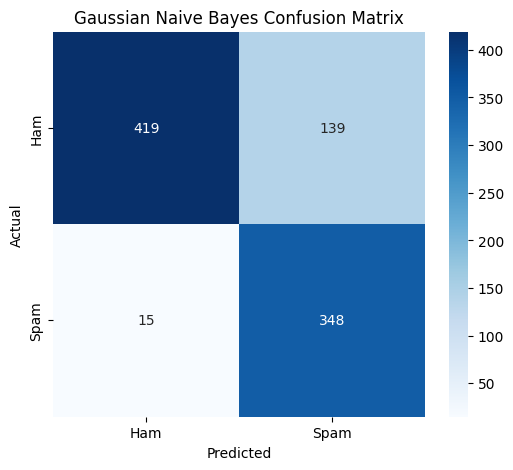

              precision    recall  f1-score   support

           0       0.97      0.75      0.84       558
           1       0.71      0.96      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.87      0.83      0.83       921



In [39]:
best_nb = GaussianNB()

best_nb.fit(X_train, y_train)

y_pred = best_nb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

In [40]:
k_values = range(1, 11)

knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    start = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = knn.predict(X_test)
    pred_time = time.time() - start

    y_score = knn.predict_proba(X_test)[:, 1]

    knn_results.append([
        k,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_score),
        train_time,
        pred_time
    ])

knn_df = pd.DataFrame(
    knn_results,
    columns=[
        "K",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "Training Time",
        "Prediction Time"
    ]
)

knn_df

,K,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,1,0.895765,0.867769,0.867769,0.867769,0.890874,0.003249,0.071486
1,2,0.893594,0.931596,0.787879,0.853731,0.922798,0.001787,0.038630
2,3,0.895765,0.882521,0.848485,0.865169,0.931357,0.002011,0.053118
3,4,0.890337,0.899390,0.812672,0.853835,0.936693,0.002216,0.053853
4,5,0.902280,0.876033,0.876033,0.876033,0.941855,0.002383,0.051329
5,6,0.896851,0.898810,0.831956,0.864092,0.944156,0.002280,0.039422
6,7,0.895765,0.876056,0.856749,0.866295,0.946439,0.001853,0.042735
7,8,0.895765,0.903323,0.823691,0.861671,0.948996,0.001889,0.043334
8,9,0.894680,0.886628,0.840220,0.862801,0.950087,0.004601,0.071915
9,10,0.888165,0.891566,0.815427,0.851799,0.951413,0.002714,0.077514


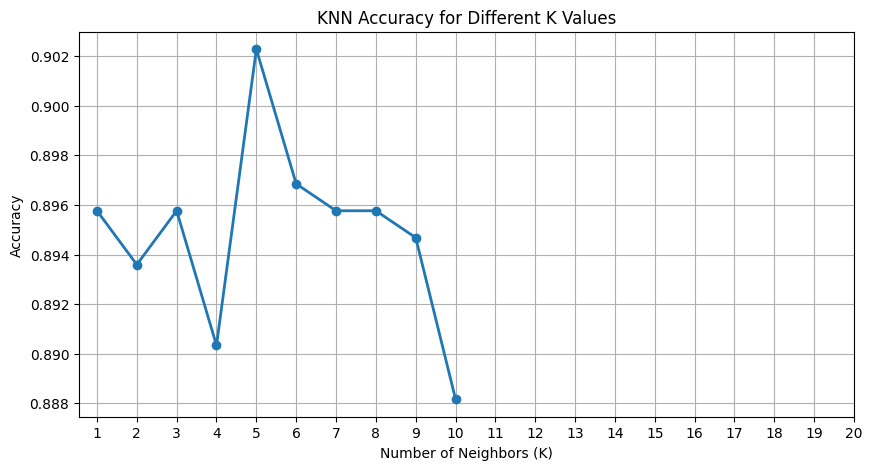

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    knn_df["K"],
    knn_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 21))
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True)

plt.show()

Best K: 5


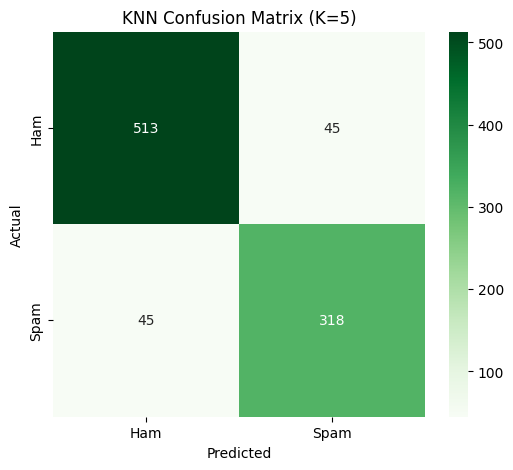

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       558
           1       0.88      0.88      0.88       363

    accuracy                           0.90       921
   macro avg       0.90      0.90      0.90       921
weighted avg       0.90      0.90      0.90       921



In [42]:
# robustly get the best K even if the 'K' column name is missing or columns/indices differ
idx = knn_df["Accuracy"].idxmax()

row = knn_df.loc[idx]

if "K" in knn_df.columns:
    best_k = row["K"]
else:
    # assume the first column contains the K values
    best_k = row.iloc[0]

best_k = int(best_k)
print("Best K:", best_k)

best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"KNN Confusion Matrix (K={best_k})")
# create images directory if it does not exist to avoid save errors
import os
os.makedirs("images", exist_ok=True)
plt.savefig(f"images/knn_confusion_matrix_k_{best_k}.png", dpi=300, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred))

In [19]:
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

print("\nGrid Search Time:")
print(f"{grid_time:.4f} seconds")


Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}

Best Cross Validation Accuracy:
0.9195652173913043

Grid Search Time:
32.8716 seconds


Accuracy : 0.9142236699239956
Precision: 0.9355828220858896
Recall   : 0.8402203856749312
F1 Score : 0.8853410740203193
ROC AUC  : 0.9563178214204606


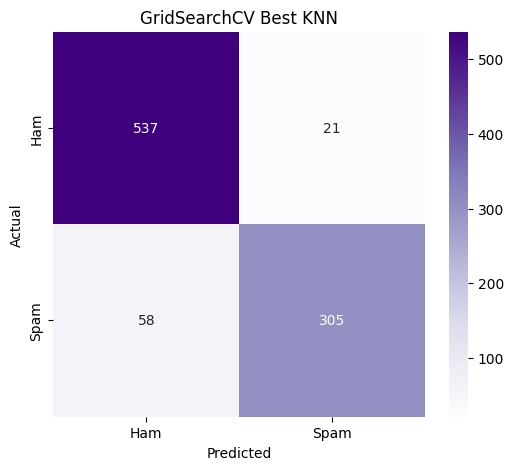

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       558
           1       0.94      0.84      0.89       363

    accuracy                           0.91       921
   macro avg       0.92      0.90      0.91       921
weighted avg       0.92      0.91      0.91       921



In [20]:
best_grid = grid_search.best_estimator_

y_pred = best_grid.predict(X_test)
y_prob = best_grid.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GridSearchCV Best KNN")
plt.show()

print(classification_report(y_test, y_pred))

In [21]:
param_dist = {
    "n_neighbors": list(range(1, 31)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

start = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

print("\nRandom Search Time:")
print(f"{random_time:.4f} seconds")

Best Parameters:
{'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}

Best Cross Validation Accuracy:
0.9157608695652174

Random Search Time:
6.4397 seconds


Accuracy : 0.9131378935939196
Precision: 0.9149560117302052
Recall   : 0.859504132231405
F1 Score : 0.8863636363636364
ROC AUC  : 0.9513783978593363


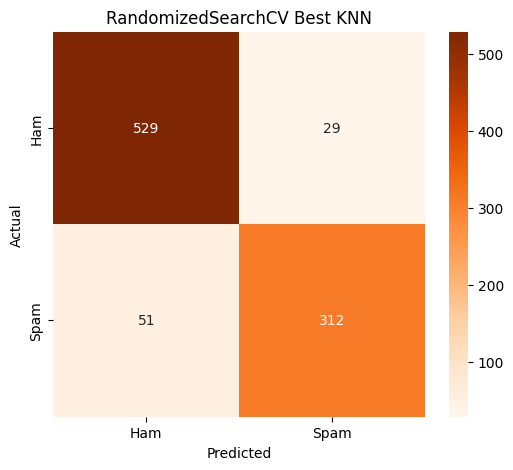

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       558
           1       0.91      0.86      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921



In [22]:
best_random = random_search.best_estimator_

y_pred = best_random.predict(X_test)
y_prob = best_random.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RandomizedSearchCV Best KNN")
plt.show()

print(classification_report(y_test, y_pred))

In [23]:
algorithms = ["auto", "ball_tree", "kd_tree", "brute"]

algorithm_results = []

for algo in algorithms:
    knn = KNeighborsClassifier(
        n_neighbors=int(best_k),
        algorithm=algo
    )

    start = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = knn.predict(X_test)
    pred_time = time.time() - start

    algorithm_results.append([
        algo,
        accuracy_score(y_test, y_pred),
        train_time,
        pred_time
    ])

algorithm_df = pd.DataFrame(
    algorithm_results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Training Time",
        "Prediction Time"
    ]
)

algorithm_df

,Algorithm,Accuracy,Training Time,Prediction Time
0,auto,0.90228,0.003983,0.081484
1,ball_tree,0.90228,0.029319,0.579599
2,kd_tree,0.90228,0.034315,0.465262
3,brute,0.90228,0.001896,0.040260


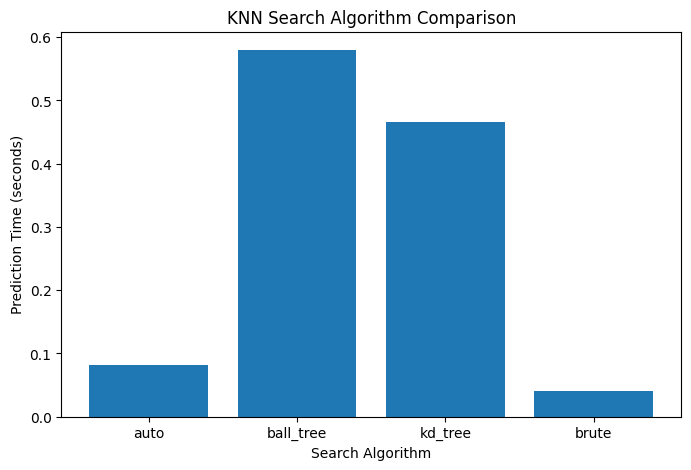

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    algorithm_df["Algorithm"],
    algorithm_df["Prediction Time"]
)

plt.xlabel("Search Algorithm")
plt.ylabel("Prediction Time (seconds)")
plt.title("KNN Search Algorithm Comparison")

plt.show()

In [25]:
models = {
    "Gaussian NB": GaussianNB(),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB(),
    "KNN": best_knn
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean Accuracy",
        "Standard Deviation"
    ]
)

cv_df

,Model,Mean Accuracy,Standard Deviation
0,Gaussian NB,0.822206,0.063702
1,Multinomial NB,0.868726,0.024483
2,Bernoulli NB,0.880891,0.053131
3,KNN,0.864594,0.057260


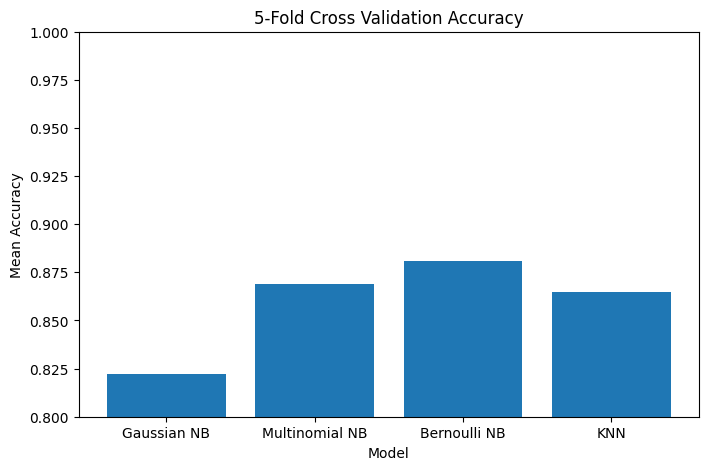

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_df["Model"],
    cv_df["Mean Accuracy"]
)

plt.ylim(0.8,1)

plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.title("5-Fold Cross Validation Accuracy")

plt.show()

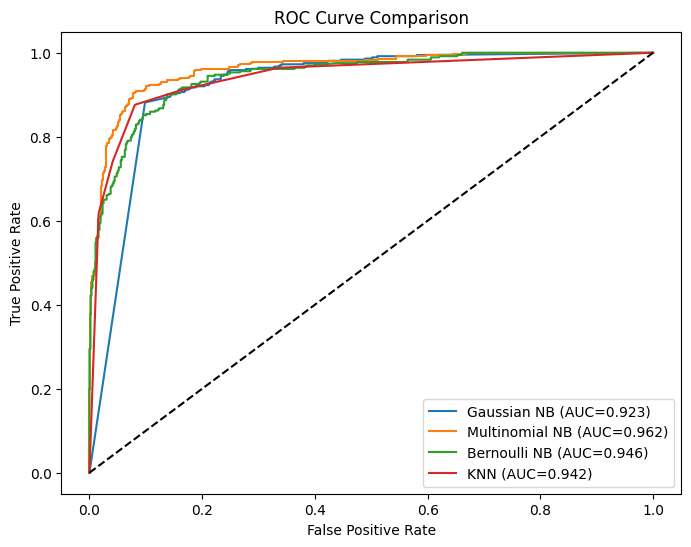

In [27]:
nb_models = {
    "Gaussian NB": GaussianNB(),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB(),
    "KNN": best_knn
}

plt.figure(figsize=(8,6))

for name, model in nb_models.items():

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

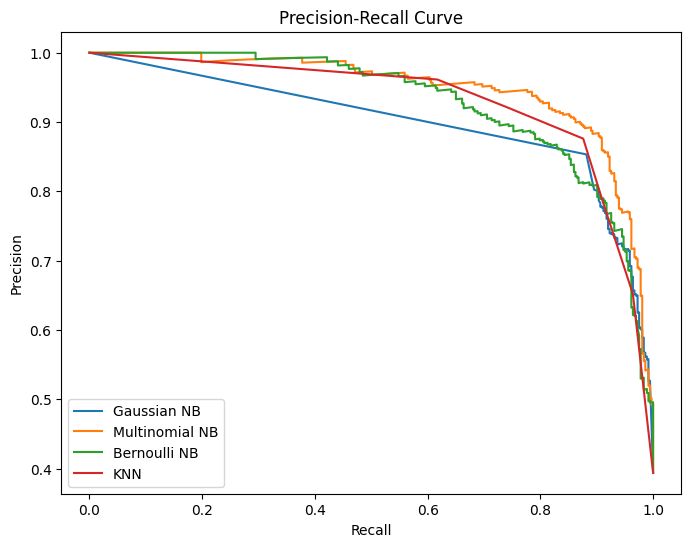

In [28]:
plt.figure(figsize=(8,6))

for name, model in nb_models.items():

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [29]:
final_results = []

for name, model in nb_models.items():

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    y_prob = model.predict_proba(X_test)[:, 1]

    final_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        train_time,
        pred_time
    ])

final_df = pd.DataFrame(
    final_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "Training Time",
        "Prediction Time"
    ]
)

final_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,KNN,0.902280,0.876033,0.876033,0.876033,0.941855,0.001862,0.060918
1,Multinomial NB,0.893594,0.943144,0.776860,0.851964,0.962454,0.005796,0.000686
2,Bernoulli NB,0.879479,0.868421,0.818182,0.842553,0.945674,0.010884,0.002240
3,Gaussian NB,0.832790,0.714579,0.958678,0.818824,0.922917,0.011095,0.003952


Model                   KNN
Accuracy            0.90228
Precision          0.876033
Recall             0.876033
F1 Score           0.876033
ROC AUC            0.941855
Training Time      0.001862
Prediction Time    0.060918
Name: 3, dtype: object


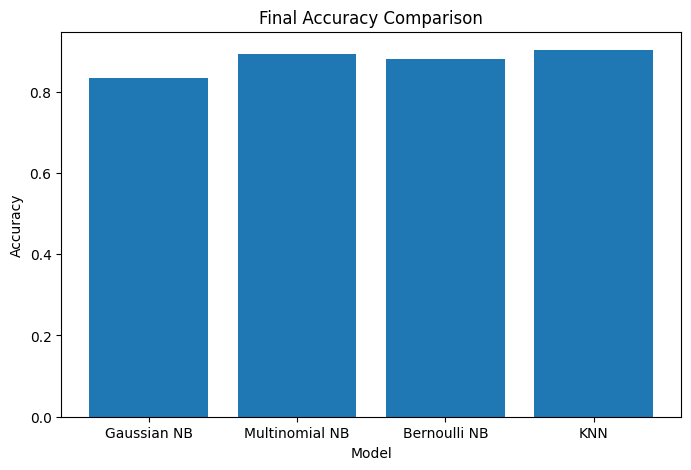

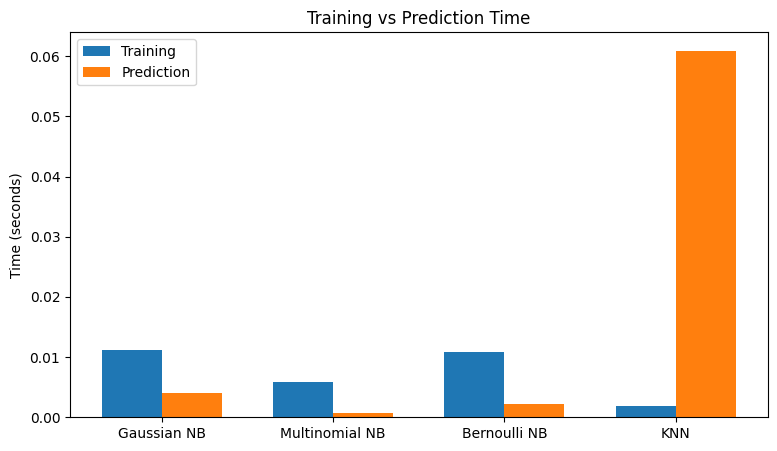

In [30]:
best_model = final_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print(best_model)

plt.figure(figsize=(8,5))

plt.bar(
    final_df["Model"],
    final_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Final Accuracy Comparison")

plt.show()

fig, ax = plt.subplots(figsize=(9,5))

x = np.arange(len(final_df))

width = 0.35

ax.bar(
    x - width/2,
    final_df["Training Time"],
    width,
    label="Training"
)

ax.bar(
    x + width/2,
    final_df["Prediction Time"],
    width,
    label="Prediction"
)

ax.set_xticks(x)
ax.set_xticklabels(final_df["Model"])

ax.set_ylabel("Time (seconds)")
ax.set_title("Training vs Prediction Time")
ax.legend()

plt.show()